# Reaction Time Analysis Gap Overlap

In [74]:
import pandas as pd
from pathlib import Path
import numpy as np
import time
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from scipy import stats
import pingouin as pg
import scikit_posthocs as sp
import statsmodels.api as sm
from scipy.stats import boxcox
from statannotations.Annotator import Annotator
from scipy.stats import pearsonr
import docx
from docx.enum.section import WD_ORIENT
from docx.enum.section import WD_SECTION
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.shared import Pt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from docx.shared import Inches


#### Functions

In [132]:
def df_to_table(doc, df):
    # Add a table to the end and create a reference variable
    t = doc.add_table(df.shape[0]+1, df.shape[1])

    # Make sure df is rounded 
    df = df.round(2)

    # Make sure table is auto fit
    for cell in t._cells:
        cell.width = docx.shared.Inches(1.0)
    
    # Set the style of the table
    table_style = doc.styles['Table Grid']

    # Add the header rows.
    for j in range(df.shape[-1]):
        t.cell(0,j).text = df.columns[j]

    # Add the rest of the data frame
    for i in range(df.shape[0]):
        for j in range(df.shape[-1]):
            t.cell(i+1,j).text = str(df.values[i,j])
    
    return doc

In [75]:
def visualize_and_summarize(df, grouping_var, dv, condition=None, fig_num=1, palette="Set2", 
                            save_dir=r"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt",
                            doc=None, dv_label=None):
    """
    Create visualizations and summary statistics for group comparisons.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe containing the data
    grouping_var : str
        Column name for the grouping variable (e.g., 'ndd', 'asd', 'affected_group')
    dv : str
        Column name for the dependent variable (e.g., 'log_rt', 'accuracy')
    condition : str, optional
        Column name for condition variable (e.g., 'condition'). If None, only grouping_var is used
    fig_num : int, default=1
        Figure number for file naming
    palette : str, default="Set2"
        Seaborn color palette name
    save_dir : str
        Directory path to save figures
    doc : docx.Document, optional
        Word document object to add results to
    dv_label : str, optional
        Label for dependent variable in plots (e.g., 'Reaction Time (log ms)')
        
    Returns:
    --------
    tuple : (fig, summary_stats_df)
        matplotlib figure and pandas DataFrame with summary statistics
    """
    
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Set default label if not provided
    if dv_label is None:
        dv_label = dv.replace('_', ' ').title()
    
    # Clean data: remove NaN values
    if condition:
        plot_data = df[[grouping_var, condition, dv, 'subject']].dropna()
        grouping_cols = [grouping_var, condition]
    else:
        plot_data = df[[grouping_var, dv, 'subject']].dropna()
        grouping_cols = [grouping_var]
    
    # Generate descriptive statistics
    if condition:
        summary_stats = plot_data.groupby(grouping_cols)[dv].agg([
            ('N', 'count'),
            ('Mean', 'mean'),
            ('SD', 'std'),
            ('Median', 'median'),
            ('Min', 'min'),
            ('Max', 'max')
        ]).reset_index()
        
        # Also get unique subject counts per group
        subject_counts = plot_data.groupby(grouping_cols)['subject'].nunique().reset_index()
        subject_counts.columns = list(grouping_cols) + ['N_Subjects']
        summary_stats = summary_stats.merge(subject_counts, on=grouping_cols)
        
    else:
        summary_stats = plot_data.groupby(grouping_var)[dv].agg([
            ('N', 'count'),
            ('Mean', 'mean'),
            ('SD', 'std'),
            ('Median', 'median'),
            ('Min', 'min'),
            ('Max', 'max')
        ]).reset_index()
        
        # Get unique subject counts
        subject_counts = plot_data.groupby(grouping_var)['subject'].nunique().reset_index()
        subject_counts.columns = [grouping_var, 'N_Subjects']
        summary_stats = summary_stats.merge(subject_counts, on=grouping_var)
    
    # Round numeric columns
    numeric_cols = ['Mean', 'SD', 'Median', 'Min', 'Max']
    summary_stats[numeric_cols] = summary_stats[numeric_cols].round(3)
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    if condition:
        # Barplot with condition on x-axis and grouping variable as hue
        ax = sns.boxplot(
            data=plot_data,
            x=condition,
            y=dv,
            hue=grouping_var,
            palette=palette
        )
        title = f'{dv_label} by {condition.replace("_", " ").title()} and {grouping_var.replace("_", " ").title()}'
        ax.set_xlabel(condition.replace('_', ' ').title(), fontsize=12)
        
    else:
        # Simple barplot with grouping variable on x-axis
        ax = sns.barplot(
            data=plot_data,
            x=grouping_var,
            y=dv,
            palette=palette,
            estimator=np.mean,
            ci=95,
            capsize=0.1,
            errwidth=1.5
        )
        title = f'{dv_label} by {grouping_var.replace("_", " ").title()}'
        ax.set_xlabel(grouping_var.replace('_', ' ').title(), fontsize=12)
    
    ax.set_ylabel(dv_label, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Improve legend
    if condition:
        plt.legend(title=grouping_var.replace('_', ' ').title(), 
                  bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    
    # Save figure
    filename = f"{fig_num}_{dv}_{grouping_var}"
    if condition:
        filename += f"_by_{condition}"
    filename += ".png"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"✓ Figure saved: {filename}")
    
    # Add to Word document if provided
    if doc is not None:
        # Add heading
        heading_text = f'{dv_label} by {grouping_var.replace("_", " ").title()}'
        if condition:
            heading_text += f' and {condition.replace("_", " ").title()}'
        doc.add_heading(heading_text, level=3)
        
        # Add figure
        doc.add_picture(save_path, width=Inches(6))
        
        # Add summary statistics table
        doc.add_heading('Descriptive Statistics', level=4)
        doc = df_to_table(doc, summary_stats)
        
        print(f"Added to Word document")
    
    plt.show()
    
    # Print summary statistics
    print(summary_stats.to_string(index=False))
    
    return plt.gcf(), summary_stats


In [76]:
# Papermill parameters
date = "2025_10_02"
participant_removal_type = "remove_min_trials"
age_group = "all"
outlier_rem = False

#### Create a word preprocessing results

In [78]:
# Create a document

doc = docx.Document()


doc = docx.Document()

# Title page
section = doc.sections[0]
#section.start_type = WD_SECTION.ODD_PAGE
#section.orientation = WD_ORIENT.LANDSCAPE
#section.page_width, section.page_height = section.page_height, section.page_width
doc.add_heading('Q1K Gap Task - Eye Tracking Preprocessing', 0)
# Add new doc section with landscape orientation
section = doc.add_section()
section.start_type = WD_SECTION.ODD_PAGE
new_width, new_height = section.page_height, section.page_width
section.orientation = WD_ORIENT.LANDSCAPE
section.page_width = new_width

## Data loading

In [79]:
# Load et file
go_df= pd.read_csv("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/gap/go_df.csv")

# Save original number of participans
intial_n_participants = go_df["subject"].nunique()
go_df        

,subject,trial_index,condition,side,rt,valid_trials,eeg_age,site,sex,asd,ndd,q1k_ID,group,age_group,developmental_group,affected_group,min_ntrials,calibration_quality
0,002Z,1,Baseline,Right,230.31,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
1,002Z,2,Gap,Right,255.00,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
2,002Z,3,Overlap,Left,323.78,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
3,002Z,4,Gap,Right,197.00,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
4,002Z,5,Baseline,Left,372.62,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9497,1256S2,34,Overlap,Right,368.29,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9498,1256S2,35,Gap,Left,247.00,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9499,1256S2,36,Baseline,Right,211.76,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9500,1256S2,37,Overlap,Right,319.85,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good


In [80]:
# Load subjects removed file
subjects_removed_df = pd.read_csv("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/missingness/subjects_removed.csv")
subjects_removed_df

,subject,status
0,004_Z,empty file
1,0105F1,empty file
2,1006P,empty file
3,1021F1,empty file
4,1045F1,empty file
...,...,...
59,1195P,"poor calibration, poor calibration, poor calib..."
60,1195S1,"poor calibration, poor calibration, poor calib..."
61,1195S2,"poor calibration, poor calibration, poor calib..."
62,1200P,"poor calibration, poor calibration, poor calib..."


In [81]:
subjects_removed_df

,subject,status
0,004_Z,empty file
1,0105F1,empty file
2,1006P,empty file
3,1021F1,empty file
4,1045F1,empty file
...,...,...
59,1195P,"poor calibration, poor calibration, poor calib..."
60,1195S1,"poor calibration, poor calibration, poor calib..."
61,1195S2,"poor calibration, poor calibration, poor calib..."
62,1200P,"poor calibration, poor calibration, poor calib..."


In [82]:
# Remove all participants from the subjects_removed df based on tiers of removal
if participant_removal_type == "remove_all": 
    # Remove all participants
    go_df = go_df[~go_df['subject'].isin(subjects_removed_df['subject'].unique())]
elif participant_removal_type == "remove_min_trials":
    # Remove only participants with empty minimum trials
    go_df = go_df[~go_df['subject'].isin(subjects_removed_df[subjects_removed_df['status'].str.contains("trials", na=False)]['subject'].unique())]

In [83]:
# Print total number of subjects and removed subjects
print(f"Total number of subjects: {intial_n_participants}")
print(f"Number of subjects removed: {len(go_df['subject'].unique())}")

Total number of subjects: 264
Number of subjects removed: 239


## Differences in reaction time 

In [84]:
go_df

,subject,trial_index,condition,side,rt,valid_trials,eeg_age,site,sex,asd,ndd,q1k_ID,group,age_group,developmental_group,affected_group,min_ntrials,calibration_quality
0,002Z,1,Baseline,Right,230.31,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
1,002Z,2,Gap,Right,255.00,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
2,002Z,3,Overlap,Left,323.78,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
3,002Z,4,Gap,Right,197.00,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
4,002Z,5,Baseline,Left,372.62,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9497,1256S2,34,Overlap,Right,368.29,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9498,1256S2,35,Gap,Left,247.00,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9499,1256S2,36,Baseline,Right,211.76,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9500,1256S2,37,Overlap,Right,319.85,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good


In [85]:
#Remove failed trials, those with negative reaction times and reaction times abova 1 second
go_rt=go_df[go_df.valid_trials]

In [86]:
go_rt

,subject,trial_index,condition,side,rt,valid_trials,eeg_age,site,sex,asd,ndd,q1k_ID,group,age_group,developmental_group,affected_group,min_ntrials,calibration_quality
0,002Z,1,Baseline,Right,230.31,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
1,002Z,2,Gap,Right,255.00,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
2,002Z,3,Overlap,Left,323.78,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
3,002Z,4,Gap,Right,197.00,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
4,002Z,5,Baseline,Left,372.62,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9497,1256S2,34,Overlap,Right,368.29,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9498,1256S2,35,Gap,Left,247.00,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9499,1256S2,36,Baseline,Right,211.76,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9500,1256S2,37,Overlap,Right,319.85,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good


In [87]:
# Descriptive statistics for RT

rt_descriptive_stats=go_rt.groupby(["condition"]).rt.describe().reset_index()
rt_descriptive_stats.round(2)


# Remove quartiles to improve readability
rt_descriptive_stats = rt_descriptive_stats.drop(columns=["25%", "75%", "50%"])

print("Descriptive Statistics by Condition:")
display(rt_descriptive_stats.round(3))

Descriptive Statistics by Condition:


,condition,count,mean,std,min,max
0,Baseline,2670.0,278.984,123.746,113.92,1172.82
1,Gap,2583.0,246.371,124.495,113.00,1177.00
2,Overlap,2586.0,341.916,165.397,114.12,1179.46


# Exploratory Gap overlap

C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3610727529.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  go_rt.condition = pd.Categorical(go_rt.condition,


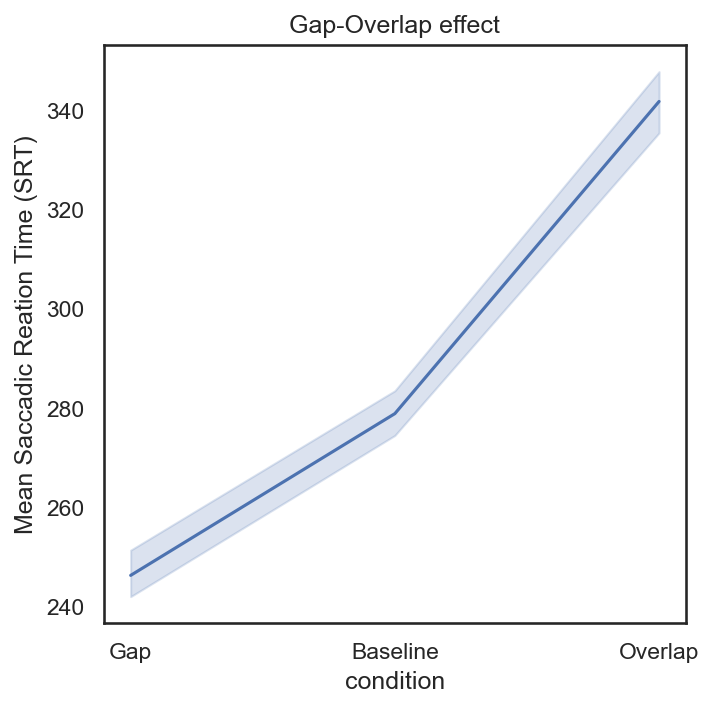

In [88]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

go_rt.condition = pd.Categorical(go_rt.condition, 
                      categories=["Gap", "Baseline", "Overlap"],
                      ordered=True)

sns.lineplot(x = 'condition', y = 'rt', data=go_rt, ax=ax)
ax.set_ylabel('Mean Saccadic Reation Time (SRT)')
ax.set_title('Gap-Overlap effect')


# Save figure 
plt.savefig("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/1_overall_reaction_time_per_condition.png")
plt.show()

### Outlier detection for each subject

In [89]:
outlier_rem=False
go_rt_sub=go_rt.copy()

In [90]:
# Remove outliers for each subject

n_before = len(go_rt)
print ("Total number of trials before removal: ", n_before)
summary_outliers= []
for sub in go_rt_sub.subject.unique():
    df=go_rt_sub.loc[go_rt_sub.subject==sub]
    # Function to perform outlier removal using IQR
    Q1 = df["rt"].quantile(0.25)
    Q3 = df["rt"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR # Should be 1.5 but can be adjusted to 3
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df["rt"] >= lower_bound) & (df["rt"] <= upper_bound)]
    df_removed = df[(df["rt"] < lower_bound) | (df["rt"] > upper_bound)]
    summary_outliers.append(df_removed)

    if outlier_rem:

        # Check if they have at least 7 trials per condition 
        if (df_filtered.groupby(["condition"]).size() < 8).all():
            continue
        # Remove the outlier trials from the main dataframe
        else:
            go_rt_sub = go_rt_sub[~go_rt_sub.index.isin(df_removed.index)]    
        print( "Subject: ", sub, "n trials removed: ", len(df_removed), "% left: ", len(df_filtered)/len(df)*100)
    else:
        print( "no outlier removal")

n_after = len(go_rt_sub)
print ("Toral number of trials after removal: ", n_after)
summary_outliers_df = pd.concat(summary_outliers, axis=0)

Total number of trials before removal:  7839
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no outlier removal
no ou

In [91]:
# Check how many subjects have at least 6 trials per condition

n_trials=go_rt_sub.groupby(["subject", "condition"]).size().reset_index(name="n_trials").pivot(index="subject", columns="condition", values="n_trials")

# Check any rows with less than 6 trials
if outlier_rem:
    not_enough_trials=n_trials[n_trials < 6].dropna(how="all")
    not_enough_trials
else:
    not_enough_trials=n_trials[n_trials < 6].dropna(how="all")

    print ("No outlier removal")  


# Add to the document
if outlier_rem:
    if len(not_enough_trials) == 0:
        doc.add_paragraph("No participants with less than 4 trials per condition", style='List Bullet')
    else:
        doc.add_heading('Participants with less than 4 trials per condition', level=3)

        doc = df_to_table(doc, not_enough_trials)

    # Remove subjects with less than 4 trials per condition
        go_rt_sub = go_rt_sub[~go_rt_sub["subject"].isin(not_enough_trials.index)]
else:
    pass


No outlier removal


C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\1394323899.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  n_trials=go_rt_sub.groupby(["subject", "condition"]).size().reset_index(name="n_trials").pivot(index="subject", columns="condition", values="n_trials")


In [131]:
## Save go_rt_sub
go_rt_sub.to_csv(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/gap/extraction/rt_per_trials.csv", index=False)

In [93]:
go_rt_sub

,subject,trial_index,condition,side,rt,valid_trials,eeg_age,site,sex,asd,ndd,q1k_ID,group,age_group,developmental_group,affected_group,min_ntrials,calibration_quality
0,002Z,1,Baseline,Right,230.31,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
1,002Z,2,Gap,Right,255.00,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
2,002Z,3,Overlap,Left,323.78,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
3,002Z,4,Gap,Right,197.00,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
4,002Z,5,Baseline,Left,372.62,True,45.88,mni,female,0.0,control,Q1K_002_Z,NaN,adult,adult,non-affected,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9497,1256S2,34,Overlap,Right,368.29,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9498,1256S2,35,Gap,Left,247.00,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9499,1256S2,36,Baseline,Right,211.76,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good
9500,1256S2,37,Overlap,Right,319.85,True,18.32,hsj,female,1.0,ndd,NaN,sibling,adult,adult,asd,True,good


In [94]:
# Calculate the number of trials removed and how many per condition
summary_outliers_df.groupby(["condition"]).size().reset_index(name="n_removed")

C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3499210188.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_outliers_df.groupby(["condition"]).size().reset_index(name="n_removed")


,condition,n_removed
0,Gap,94
1,Baseline,97
2,Overlap,270


In [95]:
# Calculate the number of trials removed per subject and condition
summary_outliers_df2=summary_outliers_df.groupby(["subject", "condition"]).size().reset_index(name="n_trials_removed").pivot(index="subject", columns="condition", values="n_trials_removed")

C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3173126136.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_outliers_df2=summary_outliers_df.groupby(["subject", "condition"]).size().reset_index(name="n_trials_removed").pivot(index="subject", columns="condition", values="n_trials_removed")


In [96]:
summary_outliers_df2

condition,Gap,Baseline,Overlap
subject,,,
0043F1,0,0,1
0050P,0,0,3
0062P,0,0,1
0064M1,0,0,1
0064S1,1,1,1
...,...,...,...
1226M1,2,0,1
1226M2,1,0,1
1256P,4,0,1


In [97]:
# Add number of trials removed to the document
doc.add_heading('Reaction time analysis', level=1)

if outlier_rem:
    doc.add_heading('Outliers removal', level=2)

    doc.add_paragraph(f"Total number of trials before removal: {n_before}", style='List Bullet')

    doc.add_paragraph(f"Total number of trials after removal: {n_after}", style='List Bullet')

    doc.add_heading('Number of trials removed per condition', level=3)

    doc = df_to_table(doc, summary_outliers_df.groupby(["condition"]).size().reset_index(name="n_removed"))
else:
    pass


#### Create a dataframe with subjects

In [98]:
# Calculate total number of trials per subject in a new column 

go_rt_sub['n_trials'] = go_rt_sub.groupby('subject')['rt'].transform('count')

#  Aggregate RT by subject and condition
go_rt_agg = go_rt_sub.groupby(["subject", "condition"])["rt"].mean().reset_index()

#  Get demographic info (one row per subject)
demo_cols = ['subject', 'ndd', 'eeg_age', 'site', 'sex', 'asd', 'developmental_group', 'affected_group','n_trials']
demo_df = go_rt_sub[demo_cols].drop_duplicates(subset=['subject'])

#  Merge demographics back
go_rt_sub = go_rt_agg.merge(demo_df, on='subject', how='left')

C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\1395849464.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  go_rt_agg = go_rt_sub.groupby(["subject", "condition"])["rt"].mean().reset_index()


In [99]:
go_rt_sub

,subject,condition,rt,ndd,eeg_age,site,sex,asd,developmental_group,affected_group,n_trials
0,002Z,Gap,213.916667,control,45.88,mni,female,0.0,adult,non-affected,35
1,002Z,Baseline,270.945000,control,45.88,mni,female,0.0,adult,non-affected,35
2,002Z,Overlap,318.220909,control,45.88,mni,female,0.0,adult,non-affected,35
3,0042P,Gap,241.000000,ndd,30.97,mni,female,0.0,adult,affected,35
4,0042P,Baseline,313.200000,ndd,30.97,mni,female,0.0,adult,affected,35
...,...,...,...,...,...,...,...,...,...,...,...
712,1256S1,Baseline,207.543636,ndd,17.33,hsj,male,1.0,adolescent,asd,35
713,1256S1,Overlap,292.319167,ndd,17.33,hsj,male,1.0,adolescent,asd,35
714,1256S2,Gap,309.166667,ndd,18.32,hsj,female,1.0,adult,asd,35
715,1256S2,Baseline,322.362500,ndd,18.32,hsj,female,1.0,adult,asd,35


In [100]:
go_rt_sub

,subject,condition,rt,ndd,eeg_age,site,sex,asd,developmental_group,affected_group,n_trials
0,002Z,Gap,213.916667,control,45.88,mni,female,0.0,adult,non-affected,35
1,002Z,Baseline,270.945000,control,45.88,mni,female,0.0,adult,non-affected,35
2,002Z,Overlap,318.220909,control,45.88,mni,female,0.0,adult,non-affected,35
3,0042P,Gap,241.000000,ndd,30.97,mni,female,0.0,adult,affected,35
4,0042P,Baseline,313.200000,ndd,30.97,mni,female,0.0,adult,affected,35
...,...,...,...,...,...,...,...,...,...,...,...
712,1256S1,Baseline,207.543636,ndd,17.33,hsj,male,1.0,adolescent,asd,35
713,1256S1,Overlap,292.319167,ndd,17.33,hsj,male,1.0,adolescent,asd,35
714,1256S2,Gap,309.166667,ndd,18.32,hsj,female,1.0,adult,asd,35
715,1256S2,Baseline,322.362500,ndd,18.32,hsj,female,1.0,adult,asd,35


#### Descriptive statistics by NDD

In [101]:
# Create a table with the rt time descriptive stats for both groups
rt_groups=go_rt_sub.groupby(["ndd", "condition"])["rt"].describe().reset_index()

# Round  and select important columns
rt_groups=rt_groups[["ndd", "condition", "mean", "std"]].round(2)

# Create table for combined groups

rt_combined=go_rt_sub.groupby(["subject", "condition"])["rt"].mean().reset_index().groupby(["condition"])["rt"].describe().reset_index()

# Round and select important columns
rt_combined=rt_combined[["condition", "mean", "std"]].round(2)
rt_combined["ndd"]="combined"

# Merge tables
rt_combined=pd.concat([rt_groups, rt_combined], axis=0)

# Pivot table
rt_combined = rt_combined.pivot(index="ndd", columns="condition", values=["mean", "std"]).reset_index()


# Add to the document
doc.add_heading('Reaction Time descriptive stats by NDD', level=3)

doc = df_to_table(doc, rt_combined)
rt_combined

C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\2231822746.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_groups=go_rt_sub.groupby(["ndd", "condition"])["rt"].describe().reset_index()
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\2231822746.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_combined=go_rt_sub.groupby(["subject", "condition"])["rt"].mean().reset_index().groupby(["condition"])["rt"].describe().reset_index()
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\2231822746.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versio

ndd    mean                     std                 
condition               Gap Baseline Overlap    Gap Baseline Overlap
0          combined  247.53   281.07  344.15  64.49    64.14   83.57
1           control  248.17   279.58  344.73  61.62    56.21   84.46
2               ndd  247.64   283.26  344.56  67.29    71.37   82.64

#### Descriptive statistics by ASD

In [102]:
# Create a table with the rt time descriptive stats for both groups
rt_groups=go_rt_sub.groupby(["asd", "condition"])["rt"].describe().reset_index()

# Round  and select important columns
rt_groups=rt_groups[["asd", "condition", "mean", "std"]].round(2)

# Create table for combined groups

rt_combined=go_rt_sub.groupby(["subject", "condition"])["rt"].mean().reset_index().groupby(["condition"])["rt"].describe().reset_index()

# Round and select important columns
rt_combined=rt_combined[["condition", "mean", "std"]].round(2)
rt_combined["asd"]="combined"

# Merge tables
rt_combined=pd.concat([rt_groups, rt_combined], axis=0)

# Pivot table
rt_combined = rt_combined.pivot(index="asd", columns="condition", values=["mean", "std"]).reset_index()


# Add to the document
doc.add_heading('Reaction Time descriptive stats by ASD', level=3)

doc = df_to_table(doc, rt_combined)
rt_combined

C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\4212712804.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_groups=go_rt_sub.groupby(["asd", "condition"])["rt"].describe().reset_index()
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\4212712804.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_combined=go_rt_sub.groupby(["subject", "condition"])["rt"].mean().reset_index().groupby(["condition"])["rt"].describe().reset_index()
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\4212712804.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versio

asd    mean                     std                 
condition               Gap Baseline Overlap    Gap Baseline Overlap
0               0.0  247.48   278.64  344.44  62.66    60.51   83.71
1               1.0  249.26   291.29  346.63  72.54    77.33   83.51
2          combined  247.53   281.07  344.15  64.49    64.14   83.57

#### Descriptive statistics by Affected Group

In [103]:
# Create a table with the rt time descriptive stats for both groups
rt_groups=go_rt_sub.groupby(["affected_group", "condition"])["rt"].describe().reset_index()

# Round  and select important columns
rt_groups=rt_groups[["affected_group", "condition", "mean", "std"]].round(2)

# Create table for combined groups

# Pivot table
rt_combined = rt_groups.pivot(index="affected_group", columns="condition", values=["mean", "std"]).reset_index()


# Add to the document
doc.add_heading('Reaction Time descriptive stats by ASD', level=3)

doc = df_to_table(doc, rt_combined)
rt_combined

C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\994266220.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rt_groups=go_rt_sub.groupby(["affected_group", "condition"])["rt"].describe().reset_index()


affected_group    mean                     std                 
condition                    Gap Baseline Overlap    Gap Baseline Overlap
0               affected  246.50   277.56  343.09  63.82    66.80   82.60
1                    asd  249.26   291.29  346.63  72.54    77.33   83.51
2           non-affected  247.41   278.93  343.74  61.92    56.43   84.81

## Statistical Assumptions

In [104]:
# Add log_rt to the df
go_grouped=go_rt_sub.copy()

In [105]:
go_grouped

,subject,condition,rt,ndd,eeg_age,site,sex,asd,developmental_group,affected_group,n_trials
0,002Z,Gap,213.916667,control,45.88,mni,female,0.0,adult,non-affected,35
1,002Z,Baseline,270.945000,control,45.88,mni,female,0.0,adult,non-affected,35
2,002Z,Overlap,318.220909,control,45.88,mni,female,0.0,adult,non-affected,35
3,0042P,Gap,241.000000,ndd,30.97,mni,female,0.0,adult,affected,35
4,0042P,Baseline,313.200000,ndd,30.97,mni,female,0.0,adult,affected,35
...,...,...,...,...,...,...,...,...,...,...,...
712,1256S1,Baseline,207.543636,ndd,17.33,hsj,male,1.0,adolescent,asd,35
713,1256S1,Overlap,292.319167,ndd,17.33,hsj,male,1.0,adolescent,asd,35
714,1256S2,Gap,309.166667,ndd,18.32,hsj,female,1.0,adult,asd,35
715,1256S2,Baseline,322.362500,ndd,18.32,hsj,female,1.0,adult,asd,35


#### Assumption of normality

In [106]:
pg.normality(data=go_grouped, dv='rt', group='condition')

,W,pval,normal
condition,,,
Gap,0.950347,2.717429e-07,False
Baseline,0.936986,1.322127e-08,False
Overlap,0.978485,1.074430e-03,False


In [107]:
#Applied various trasnformations
go_grouped["log_rt"]=np.log(go_grouped.rt)
go_grouped["sqrt_rt"]=np.sqrt(go_grouped.rt)
go_grouped["reciprocal_rt"] = boxcox(go_grouped.rt,-0.5)

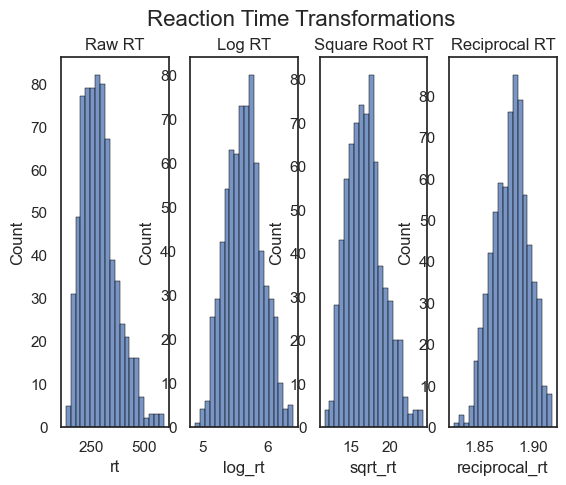

In [108]:
fig, axs = plt.subplots(ncols=4)
sns.histplot(go_grouped.rt,edgecolor='black', bins=20, ax=axs[0])
sns.histplot(go_grouped.log_rt,edgecolor='black', bins=20, ax=axs[1])
sns.histplot(go_grouped.sqrt_rt,edgecolor='black', bins=20, ax=axs[2])
sns.histplot(go_grouped.reciprocal_rt,edgecolor='black', bins=20, ax=axs[3])


# Add tittle
fig.suptitle('Reaction Time Transformations', fontsize=16)
axs[0].set_title('Raw RT')
axs[1].set_title('Log RT')
axs[2].set_title('Square Root RT')
axs[3].set_title('Reciprocal RT')



# Save the figure
plt.savefig(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/2_rt_transformations.png")

plt.show()

# Add the figure to the document
doc.add_heading('Transformations figure  ', level=4)

doc.add_picture(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/2_rt_transformations.png", width=docx.shared.Inches(6), height=docx.shared.Inches(4))


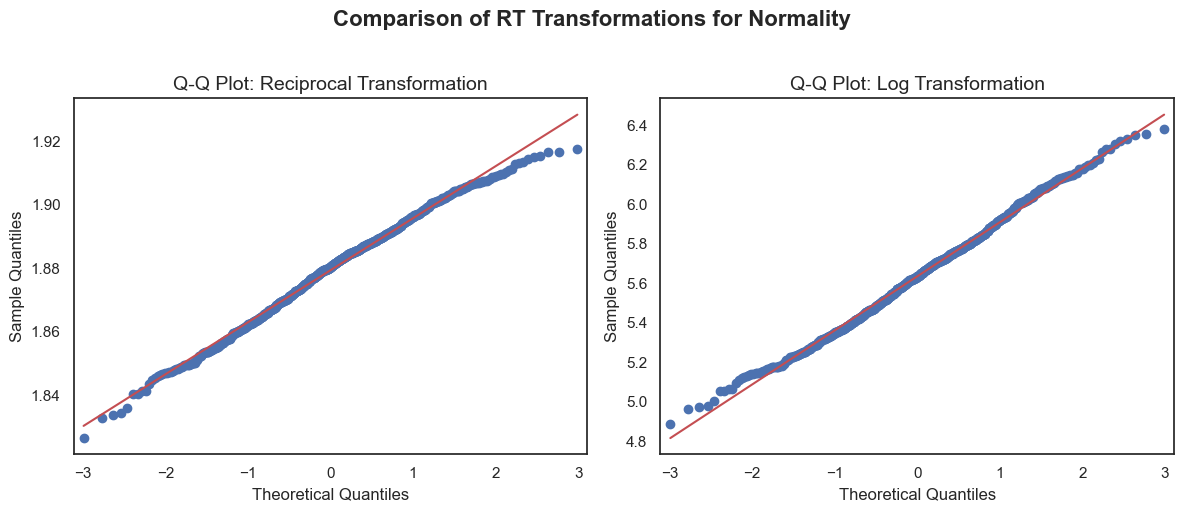

In [109]:
# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot for reciprocal transformation
sm.qqplot(go_grouped.reciprocal_rt, line='s', ax=axes[0])
axes[0].set_title('Q-Q Plot: Reciprocal Transformation', fontsize=14)
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Sample Quantiles')

# Q-Q plot for log transformation
sm.qqplot(go_grouped.log_rt, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot: Log Transformation', fontsize=14)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

# Add overall title
fig.suptitle('Comparison of RT Transformations for Normality', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()

# Save figure
plt.savefig("C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/3_qq_plot_transformations_comparison.png", 
            dpi=300, bbox_inches='tight')

plt.show()

In [110]:
# Add the following text and test to the doc 
doc.add_heading('Normality Tests for Log-Transformed RT', level=3)
doc = df_to_table(doc, pg.normality(data=go_grouped, dv='log_rt', group='condition'))
doc.add_paragraph("Log-RT values were the closest to normality based on the Q-Q plots and normality tests. Therefore, log-transformed RTs were used for subsequent analyses.", style='List Bullet')

pg.normality(data=go_grouped, dv='log_rt', group='condition')


,W,pval,normal
condition,,,
Gap,0.986365,0.022214,False
Baseline,0.986060,0.019634,False
Overlap,0.994970,0.619754,True


C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3685761097.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax=sns.barplot(x="condition", y="rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2,
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3685761097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x="condition", y="rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2,
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3685761097.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


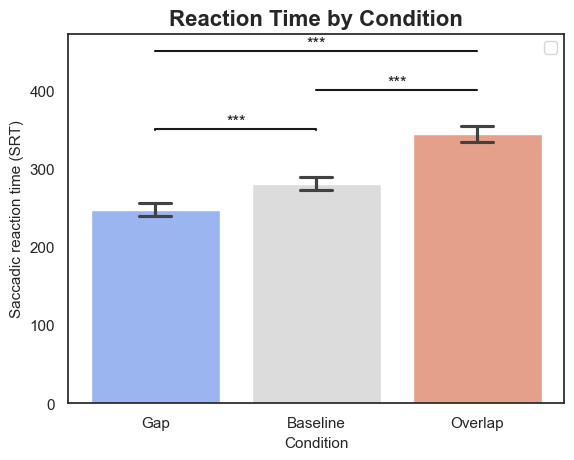

In [111]:

sns.set_theme(style='white')
order = ["Gap", "Baseline","Overlap"]
ax=sns.barplot(x="condition", y="rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2,
            palette="coolwarm").set_title("",fontsize=18)

plt.grid(False)
plt.ylabel('Saccadic reaction time (SRT)',fontsize=11)
plt.xlabel('Condition',fontsize=11)
plt.legend(loc='upper right')

x1, x2 = 0,2 
y, h, col = 450 + 0.5, 0.2, 'k'
plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h, "***", ha='center', va='bottom', color=col)

x3, x2 = 0,1 
y, h, col = 350 + 0.5, 0.2, 'k'

plt.plot([x3, x3, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x3+x2)*.5, y+h, "***", ha='center', va='bottom', color=col)

x3, x2 = 1,2
y, h, col = 400 + 0.5, 0.2, 'k'

plt.plot([x3, x3, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x3+x2)*.5, y+h, "***", ha='center', va='bottom', color=col)

# Add title in bold
plt.title('Reaction Time by Condition', fontsize=16, fontweight='bold')


plt.savefig(f"C:/Users/gabot/OneDrive - McGill University/Desktop/Github_repos/q1k_neurosubs/figures/supplementary/rt/4_rt_conditions.png")
plt.show()


# Add the figure to the document
doc.add_heading('Reaction Time figure ', level=4)

doc.add_picture(f"C:/Users/gabot/OneDrive - McGill University/Desktop/Github_repos/q1k_neurosubs/figures/supplementary/rt/4_rt_conditions.png", width=docx.shared.Inches(6), height=docx.shared.Inches(4))

#### Assumption of sphericity (Mauchly’s test)

In [112]:
pg.sphericity(data=go_grouped, dv='log_rt', subject='subject', within='condition', method='mauchly')

SpherResults(spher=False, W=np.float64(0.9186093570296936), chi2=np.float64(20.119954066846137), dof=2, pval=np.float64(4.275702564876682e-05))

In [113]:
# Add to doc 
if pg.sphericity(data=go_grouped, dv='log_rt', subject='subject', within='condition')[-1] < 0.05:
    p16= "Assumption of sphericity is violated : " + str(pg.sphericity(data=go_grouped, dv='log_rt', subject='subject', within='condition')[-1].round(4))
    print(p16)
    # Add to doc 
    doc.add_paragraph(p16, style='List Bullet')
else:
    print("Assumption of sphericity is met")
    doc.add_paragraph("Assumption of sphericity is met", style='List Bullet')


Assumption of sphericity is violated : 0.0


#### Assumptions of Levenes test

In [114]:
# Calculate Levene's test for homogeneity of variance
levene_result = pg.homoscedasticity(data=go_grouped, dv='log_rt', group='ndd', method='levene')
pval = levene_result["pval"].values[0]

# Display results
print(f"Levene's test p-value: {pval:.4f}")

Levene's test p-value: 0.0404


In [115]:
if pval < 0.05:
    interpretation = f"Assumption of homoscedasticity is violated (p = {pval:.4f})"
    print(f"{interpretation}")
    doc.add_paragraph(interpretation, style='List Bullet')
    doc.add_paragraph("Consider using Welch's ANOVA or non-parametric alternatives", style='List Bullet')
else:
    interpretation = f"Assumption of homoscedasticity is met (p = {pval:.4f})"
    print(f"✓ {interpretation}")
    doc.add_paragraph(interpretation, style='List Bullet')

Assumption of homoscedasticity is violated (p = 0.0404)


In [116]:
#### Statistical Approach Based on Assumption Violations

# Test assumptions
normality_result = pg.normality(data=go_grouped, dv='log_rt', group='condition')
normality_met = (normality_result['pval'] > 0.05).all()

levene_result = pg.homoscedasticity(data=go_grouped, dv='log_rt', group='condition', method='levene')
homoscedasticity_met = levene_result["pval"].values[0] > 0.05


# Determine appropriate statistical test
if not normality_met or not homoscedasticity_met:
    print("Assumptions violated")
    doc.add_heading('Non-Parametric Analysis (Friedman Test)', level=2)
    doc.add_paragraph(
        "Due to violation of parametric assumptions (normality and/or homoscedasticity), "
        "we employed the Friedman test, a non-parametric alternative to repeated measures ANOVA. ",
        style='Body Text'
    )
    
    # Friedman test
    friedman_result = pg.friedman(data=go_grouped, dv="log_rt", within="condition", subject="subject")
    friedman_pval = friedman_result['p-unc'].values[0]
    
    print(f"\n Friedman Test Results:")
    print(f"   χ²({friedman_result['ddof1'].values[0]}) = {friedman_result['Q'].values[0]:.3f}, p = {friedman_pval:.4f}")
    
    # Add to document
    doc.add_paragraph(f"Friedman χ²({friedman_result['ddof1'].values[0]}) = {friedman_result['Q'].values[0]:.3f}, p = {friedman_pval:.4f}", style='List Bullet')
    doc = df_to_table(doc, friedman_result.round(4))
else:
    print("Assumptions met - Proceeding with parametric approach")
    doc.add_heading('Parametric Analysis (Repeated Measures ANOVA)', level=2)
    doc.add_paragraph(
        "Parametric assumptions were satisfied. Repeated measures ANOVA was used to compare "
        "reaction times across conditions.",
        style='Body Text'
    )
    
    # Run repeated measures ANOVA
    rm_anova = pg.rm_anova(data=go_grouped, dv='log_rt', within='condition', subject='subject')
    
    print(f"\n📊 Repeated Measures ANOVA Results:")
    print(rm_anova.round(4))
    
    doc = df_to_table(doc, rm_anova.round(4))
    
    # Post-hoc if significant
    if rm_anova['p-unc'].values[0] < 0.05:
        doc.add_heading('Post-hoc Pairwise Comparisons (Bonferroni)', level=3)
        posthoc_result = pg.pairwise_tests(
            data=go_grouped, 
            dv='log_rt', 
            within='condition', 
            subject='subject',
            padjust='bonf'
        )
        doc = df_to_table(doc, posthoc_result.round(4))

# Add statistical approach summary
doc.add_heading('Statistical Approach Summary', level=3)
approach = "Non-parametric (Friedman test)" if (not normality_met or not homoscedasticity_met) else "Parametric (Repeated Measures ANOVA)"
doc.add_paragraph(f"Final approach: {approach}", style='List Bullet')

Assumptions violated

 Friedman Test Results:
   χ²(2) = 252.410, p = 0.0000


### Posthocs

In [117]:
# IF not met

# Post-hoc tests if significant
if friedman_pval < 0.05:
    print("   Significant main effect detected - Running post-hoc tests")
    doc.add_heading('Post-hoc Pairwise Comparisons (Conover-Friedman)', level=3)
    doc.add_paragraph(
                "Conover-Friedman test with FDR (Benjamini-Hochberg) correction for multiple comparisons.",
        style='Body Text'
    )
    
    # Ensure one observation per subject x condition (avoid duplicated block entries)
    posthoc_input = go_grouped.groupby(["subject", "condition"])["log_rt"].mean().reset_index()

    # Convert to wide format (subjects as rows, conditions as columns)
    posthoc_wide = posthoc_input.pivot(index="subject", columns="condition", values="log_rt")
    
    posthoc_result = sp.posthoc_conover_friedman(
            a=posthoc_wide,
            p_adjust="fdr_bh"
        )
        
    
    print("\n Post-hoc Pairwise Comparisons:")
    
doc = df_to_table(doc, posthoc_result.round(4))
doc.add_paragraph("Post-hoc tests were conducted to explore significant pairwise differences.", style='Body Text')
posthoc_result

   Significant main effect detected - Running post-hoc tests

 Post-hoc Pairwise Comparisons:


C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3796640917.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  posthoc_input = go_grouped.groupby(["subject", "condition"])["log_rt"].mean().reset_index()


,Gap,Baseline,Overlap
Gap,1.000000e+00,7.938457e-24,4.724316e-79
Baseline,7.938457e-24,1.000000e+00,1.022520e-30
Overlap,4.724316e-79,1.022520e-30,1.000000e+00


## Data Visualization
### 11.1 Reaction time by NDD

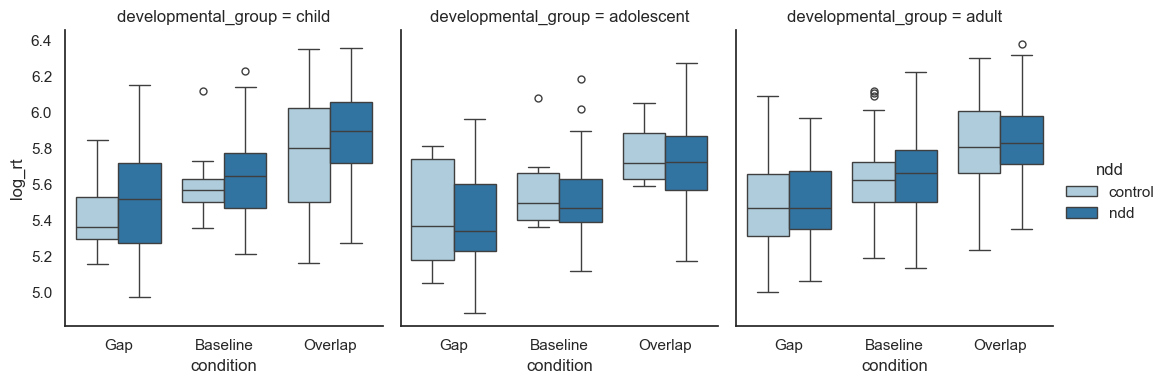

In [118]:
# Faceted boxplot using catplot to show ASD differences within each developmental_group
g = sns.catplot(
    data=go_grouped,
    x="condition",
    y="log_rt",
    col="developmental_group",        # facet by age group (child/adolescent/adult)
    col_order=["child", "adolescent", "adult"],  # specify panel order
    kind="box",
    hue="ndd",                        # show ASD vs control within each facet
    palette="Paired",
    height=4,
    aspect=0.9,
    sharey=True,
    dodge=True,
    legend=True                      # disable automatic legend to avoid duplicates
)


 

#plt.ylim([0.7,1.2])

# Save the figure
g.savefig(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/5_reaction_time_by_NDD_conditions.png")

plt.show()

# Add the figure to the document
doc.add_heading('Reaction Time figure ', level=4)

doc.add_picture(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/5_reaction_time_by_NDD_conditions.png",
                width=docx.shared.Inches(6), height=docx.shared.Inches(4))

### 11.2 Accuracy by ASD

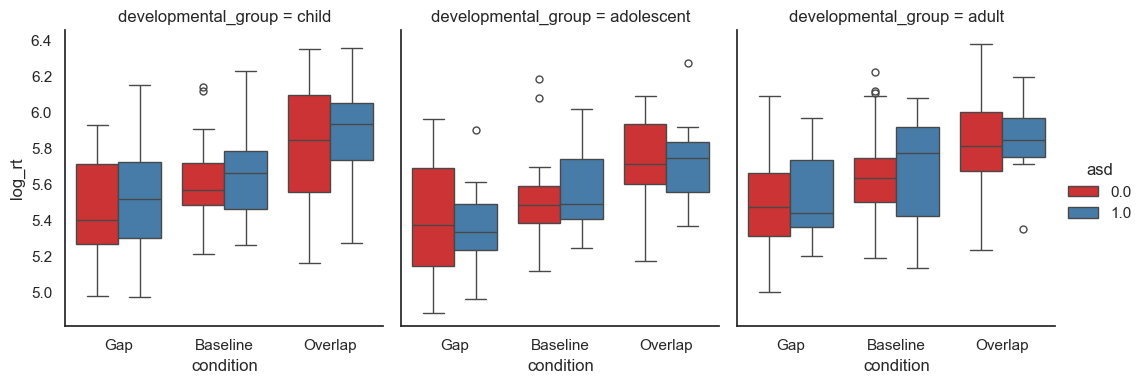

In [119]:
# Faceted boxplot using catplot to show ASD differences within each developmental_group
g = sns.catplot(
    data=go_grouped,
    x="condition",
    y="log_rt",
    col="developmental_group",        # facet by age group (child/adolescent/adult)
    col_order=["child", "adolescent", "adult"],  # specify panel order
    kind="box",
    hue="asd",                        # show ASD vs control within each facet
    palette="Set1",
    height=4,
    aspect=0.9,
    sharey=True,
    dodge=True,
    legend=True                      # disable automatic legend to avoid duplicates
)



# Save figure
save_path = r"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/6_reaction_time_by_ASD_conditions_by_devgroup.png"
g.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

# Add the figure to the document
doc.add_heading('Reaction Time figure ', level=4)

doc.add_picture(save_path, width=docx.shared.Inches(9), height=docx.shared.Inches(4))


### 11.2 Accuracy by Affected Group

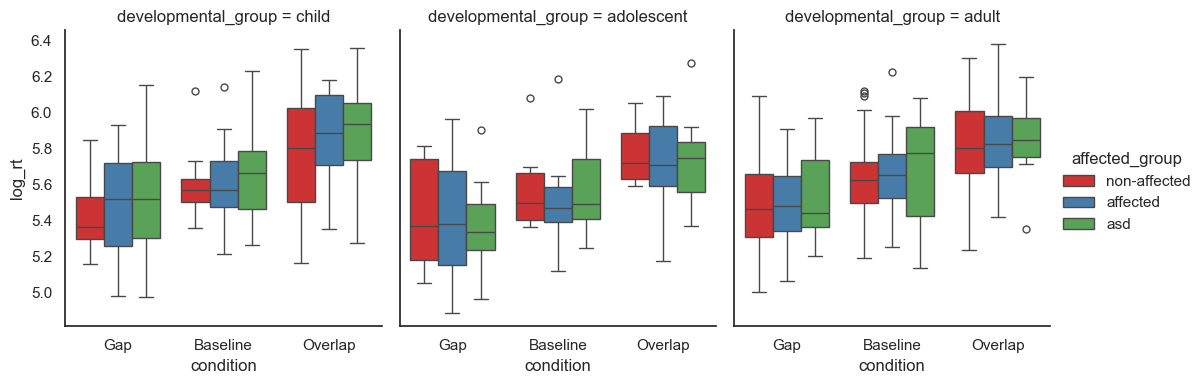

In [120]:
# Faceted boxplot using catplot to show ASD differences within each developmental_group
g = sns.catplot(
    data=go_grouped,
    x="condition",
    y="log_rt",
    col="developmental_group",        # facet by age group (child/adolescent/adult)
    col_order=["child", "adolescent", "adult"],  # specify panel order
    kind="box",
    hue="affected_group",                        # show ASD vs control within each facet
    palette="Set1",
    height=4,
    aspect=0.9,
    sharey=True,
    dodge=True,
    legend=True                      # disable automatic legend to avoid duplicates
)



# Save figure
save_path = r"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/7_reaction_time_by_affected_conditions.png"
g.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

# Add the figure to the document
doc.add_heading('Accuracy figure ', level=4)

doc.add_picture(save_path, width=docx.shared.Inches(9), height=docx.shared.Inches(4))


### 11.2 Exploratory Plots by Demographics

C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3890229069.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x="condition", y="log_rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2, hue = "ndd", ax=ax[0],
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3890229069.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x="condition", y="log_rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2, hue ="developmental_group", ax=ax[1],
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3890229069.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x="condition", y="log_rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2, hue= "sex", ax=ax[2],
C:\Users\gabot\AppData\Local\Temp\ipykernel_21324\3890229069.py:15: FutureWarning: 

The `ci` par

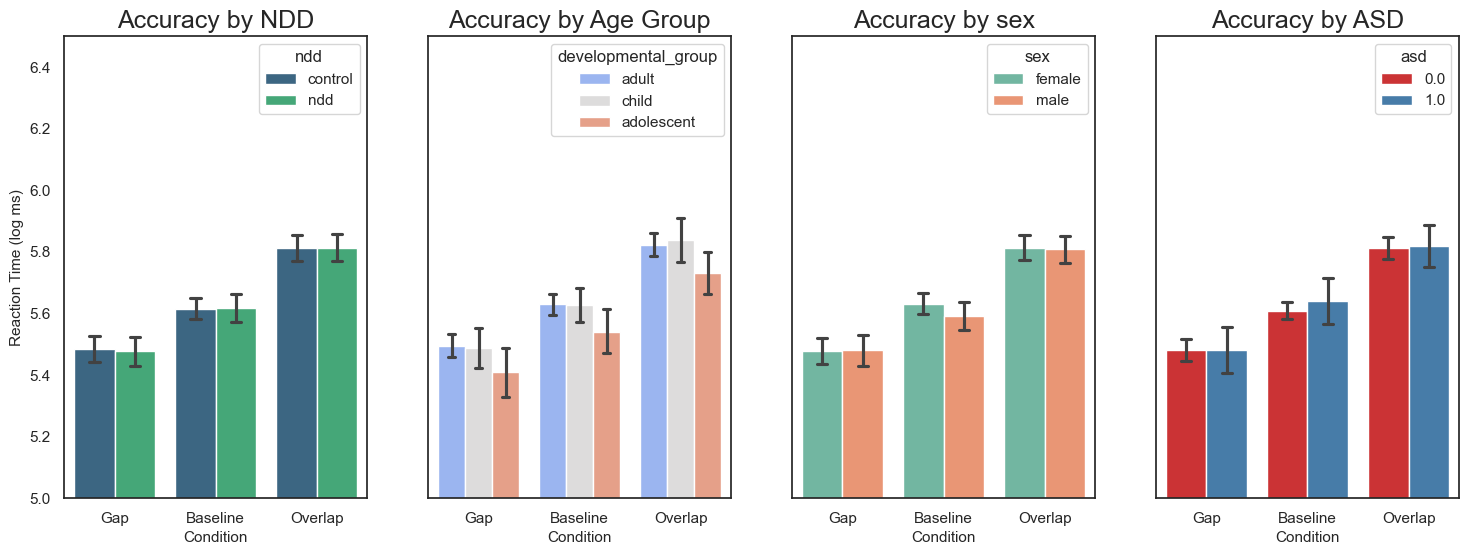

In [121]:
fig, ax = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
sns.set_theme(style="white")

order = ["Gap", "Baseline","Overlap"]
sns.barplot(x="condition", y="log_rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2, hue = "ndd", ax=ax[0],
            palette="viridis").set_title("",fontsize=18)

sns.barplot(x="condition", y="log_rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2, hue ="developmental_group", ax=ax[1],
            palette="coolwarm").set_title("",fontsize=18)

sns.barplot(x="condition", y="log_rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2, hue= "sex", ax=ax[2],
            palette="Set2").set_title("",fontsize=18)

# Test ASD  vs Control
sns.barplot(x="condition", y="log_rt", data=go_grouped,order=order,estimator=np.mean, ci=95, capsize=.2, hue = "asd", ax=ax[3],
            palette="Set1",
            ).set_title("",fontsize=18)



# Add titles to the plots
ax[0].set_title('Accuracy by NDD',fontsize=18)
ax[1].set_title('Accuracy by Age Group',fontsize=18)
ax[2].set_title('Accuracy by sex',fontsize=18)
ax[3].set_title('Accuracy by ASD',fontsize=18)

# Add labels to the plots
ax[0].set_ylabel("Reaction Time (log ms)",fontsize=11)
ax[1].set_ylabel("Reaction Time (log ms)",fontsize=11)
ax[2].set_ylabel("Reaction Time (log ms)",fontsize=11)
ax[3].set_ylabel("Reaction Time (log ms)",fontsize=11)

ax[0].set_xlabel('Condition',fontsize=11)
ax[1].set_xlabel('Condition',fontsize=11)
ax[2].set_xlabel('Condition',fontsize=11)
ax[3].set_xlabel('Condition',fontsize=11)

# Set ylim to be the same for all plots
plt.ylim([5,6.5])

# Save and add to doc 
plt.savefig(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/8_rt_conditions_grouped.png")

plt.show()

# Add the figure to the document
doc.add_heading('Reaction Time Figure by Demographics', level=4)

doc.add_picture(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/figures/supplementary/rt/8_rt_conditions_grouped.png", width=docx.shared.Inches(6), height=docx.shared.Inches(4))

### Disengagement and Facilitation

In [122]:
# Pivot the go_grouped dataframe to wide format for VIF calculation
go_dis = go_grouped.pivot(index=['subject', 'ndd', 'developmental_group', 'sex', 'asd', 'affected_group',"site", 'n_trials', 'eeg_age'],
                                          columns='condition', values='log_rt').reset_index()
go_dis

condition,subject,ndd,developmental_group,sex,asd,affected_group,site,n_trials,eeg_age,Gap,Baseline,Overlap
0,002Z,control,adult,female,0.0,non-affected,mni,35,45.88,5.365587,5.601916,5.762746
1,0042P,ndd,adult,female,0.0,affected,mni,35,30.97,5.484797,5.746842,5.785506
2,0043F1,control,adult,male,0.0,non-affected,hsj,36,58.13,5.724402,5.819220,6.009928
3,0050M1,control,adult,female,0.0,non-affected,hsj,35,37.10,5.624920,5.642784,5.693328
4,0050P,ndd,child,female,0.0,affected,hsj,33,8.07,5.616771,5.486399,6.179239
...,...,...,...,...,...,...,...,...,...,...,...,...
234,1226M2,ndd,adult,female,0.0,affected,hsj,36,36.86,5.707664,5.656889,5.971995
235,1256F1,ndd,adult,male,1.0,asd,hsj,35,45.17,5.357015,5.329388,5.352971
236,1256P,ndd,adolescent,male,0.0,affected,hsj,29,15.51,5.384036,5.119355,5.698885
237,1256S1,ndd,adolescent,male,1.0,asd,hsj,35,17.33,5.550372,5.335342,5.677846


In [123]:
# Calculate facilitation as Baseline - Gap
go_dis["facilitation"]=go_dis["Baseline"]-go_dis["Gap"]

# Add to document 
doc.add_paragraph("Variable 1: Facilitation (Baseline - Gap)", style='List Bullet')

# Calculate disengagement as Overlap - Baseline
go_dis["disengagement"]=go_dis["Overlap"]-go_dis["Baseline"]
# Add to document
doc.add_paragraph("Variable 2: Disengagement (Overlap - Baseline)", style='List Bullet')


In [124]:
go_dis

condition,subject,ndd,developmental_group,sex,asd,affected_group,site,n_trials,eeg_age,Gap,Baseline,Overlap,facilitation,disengagement
0,002Z,control,adult,female,0.0,non-affected,mni,35,45.88,5.365587,5.601916,5.762746,0.236329,0.160830
1,0042P,ndd,adult,female,0.0,affected,mni,35,30.97,5.484797,5.746842,5.785506,0.262045,0.038664
2,0043F1,control,adult,male,0.0,non-affected,hsj,36,58.13,5.724402,5.819220,6.009928,0.094818,0.190709
3,0050M1,control,adult,female,0.0,non-affected,hsj,35,37.10,5.624920,5.642784,5.693328,0.017865,0.050544
4,0050P,ndd,child,female,0.0,affected,hsj,33,8.07,5.616771,5.486399,6.179239,-0.130372,0.692840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,1226M2,ndd,adult,female,0.0,affected,hsj,36,36.86,5.707664,5.656889,5.971995,-0.050775,0.315106
235,1256F1,ndd,adult,male,1.0,asd,hsj,35,45.17,5.357015,5.329388,5.352971,-0.027627,0.023583
236,1256P,ndd,adolescent,male,0.0,affected,hsj,29,15.51,5.384036,5.119355,5.698885,-0.264681,0.579530
237,1256S1,ndd,adolescent,male,1.0,asd,hsj,35,17.33,5.550372,5.335342,5.677846,-0.215031,0.342505


In [125]:
go_grouped

,subject,condition,rt,ndd,eeg_age,site,sex,asd,developmental_group,affected_group,n_trials,log_rt,sqrt_rt,reciprocal_rt
0,002Z,Gap,213.916667,control,45.88,mni,female,0.0,adult,non-affected,35,5.365587,14.625890,1.863256
1,002Z,Baseline,270.945000,control,45.88,mni,female,0.0,adult,non-affected,35,5.601916,16.460407,1.878496
2,002Z,Overlap,318.220909,control,45.88,mni,female,0.0,adult,non-affected,35,5.762746,17.838747,1.887885
3,0042P,Gap,241.000000,ndd,30.97,mni,female,0.0,adult,affected,35,5.484797,15.524175,1.871169
4,0042P,Baseline,313.200000,ndd,30.97,mni,female,0.0,adult,affected,35,5.746842,17.697457,1.886989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,1256S1,Baseline,207.543636,ndd,17.33,hsj,male,1.0,adolescent,asd,35,5.335342,14.406375,1.861173
713,1256S1,Overlap,292.319167,ndd,17.33,hsj,male,1.0,adolescent,asd,35,5.677846,17.097344,1.883023
714,1256S2,Gap,309.166667,ndd,18.32,hsj,female,1.0,adult,asd,35,5.733881,17.583136,1.886255
715,1256S2,Baseline,322.362500,ndd,18.32,hsj,female,1.0,adult,asd,35,5.775677,17.954456,1.888607


✓ Figure saved: 8_facilitation_ndd_by_developmental_group.png
Added to Word document


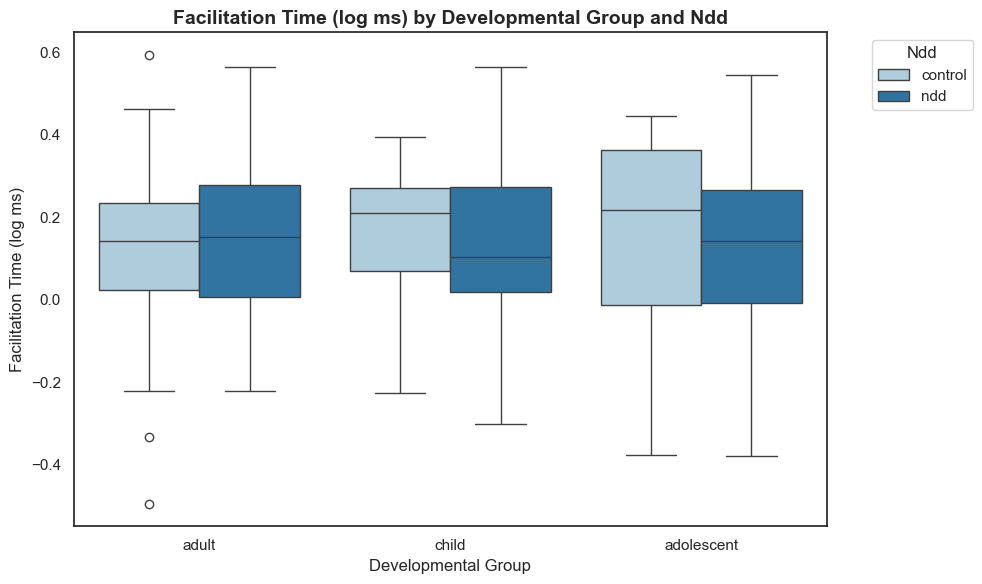

    ndd developmental_group  N  Mean    SD  Median    Min   Max  N_Subjects
control          adolescent  7 0.141 0.310   0.218 -0.376 0.446           7
control               adult 97 0.123 0.177   0.142 -0.495 0.594          97
control               child 16 0.159 0.160   0.210 -0.227 0.396          16
    ndd          adolescent 31 0.129 0.249   0.141 -0.378 0.545          31
    ndd               adult 42 0.156 0.193   0.153 -0.220 0.564          42
    ndd               child 45 0.133 0.195   0.105 -0.301 0.564          45
✓ Figure saved: 9_disengagement_ndd_by_developmental_group.png
Added to Word document


<Figure size 640x480 with 0 Axes>

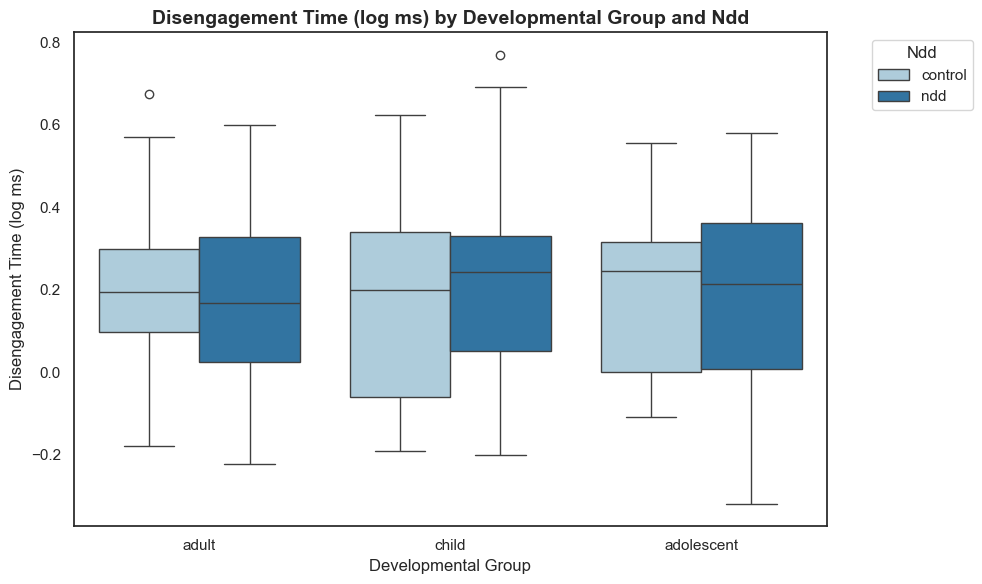

    ndd developmental_group  N  Mean    SD  Median    Min   Max  N_Subjects
control          adolescent  7 0.190 0.236   0.247 -0.108 0.557           7
control               adult 97 0.201 0.167   0.195 -0.179 0.675          97
control               child 16 0.188 0.266   0.200 -0.192 0.623          16
    ndd          adolescent 31 0.191 0.241   0.213 -0.319 0.580          31
    ndd               adult 42 0.179 0.204   0.168 -0.222 0.600          42
    ndd               child 45 0.217 0.223   0.243 -0.202 0.770          45
✓ Figure saved: 10_facilitation_asd_by_developmental_group.png
Added to Word document


<Figure size 640x480 with 0 Axes>

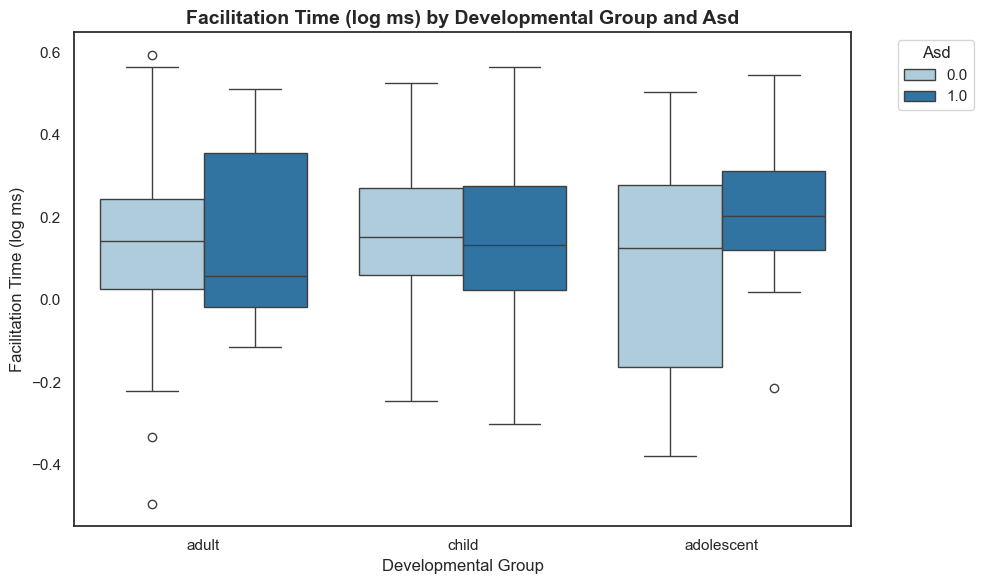

 asd developmental_group   N  Mean    SD  Median    Min   Max  N_Subjects
 0.0          adolescent  24 0.086 0.281   0.125 -0.378 0.505          24
 0.0               adult 126 0.131 0.179   0.142 -0.495 0.594         126
 0.0               child  38 0.142 0.177   0.151 -0.245 0.527          38
 1.0          adolescent  14 0.209 0.195   0.204 -0.215 0.545          14
 1.0               adult  12 0.148 0.226   0.059 -0.115 0.512          12
 1.0               child  23 0.137 0.203   0.134 -0.301 0.564          23
✓ Figure saved: 11_disengagement_asd_by_developmental_group.png
Added to Word document


<Figure size 640x480 with 0 Axes>

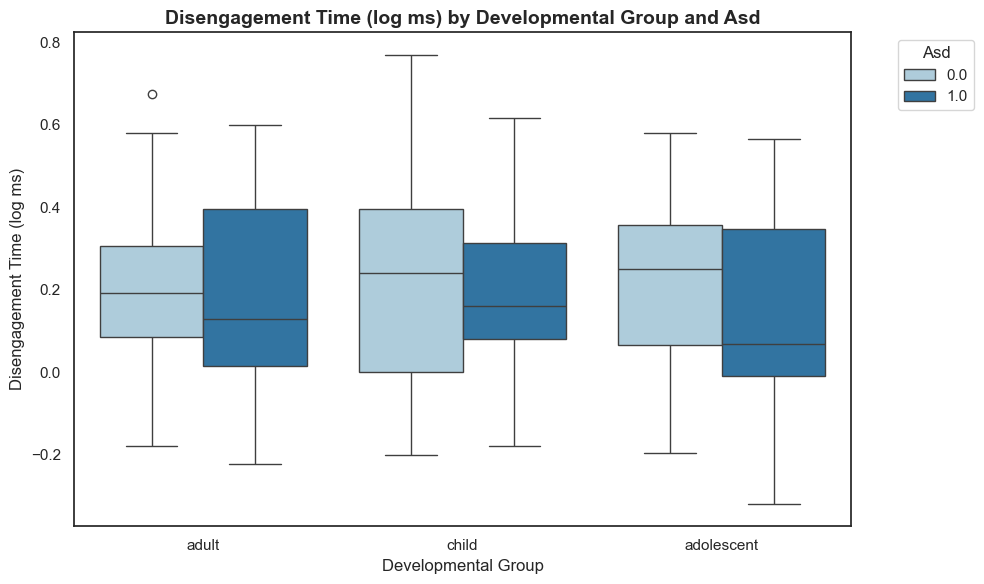

 asd developmental_group   N  Mean    SD  Median    Min   Max  N_Subjects
 0.0          adolescent  24 0.211 0.222   0.251 -0.196 0.580          24
 0.0               adult 126 0.198 0.171   0.192 -0.179 0.675         126
 0.0               child  38 0.222 0.264   0.241 -0.202 0.770          38
 1.0          adolescent  14 0.156 0.265   0.069 -0.319 0.567          14
 1.0               adult  12 0.183 0.245   0.128 -0.222 0.600          12
 1.0               child  23 0.190 0.173   0.160 -0.179 0.617          23
✓ Figure saved: 12_facilitation_affected_group_by_developmental_group.png
Added to Word document


<Figure size 640x480 with 0 Axes>

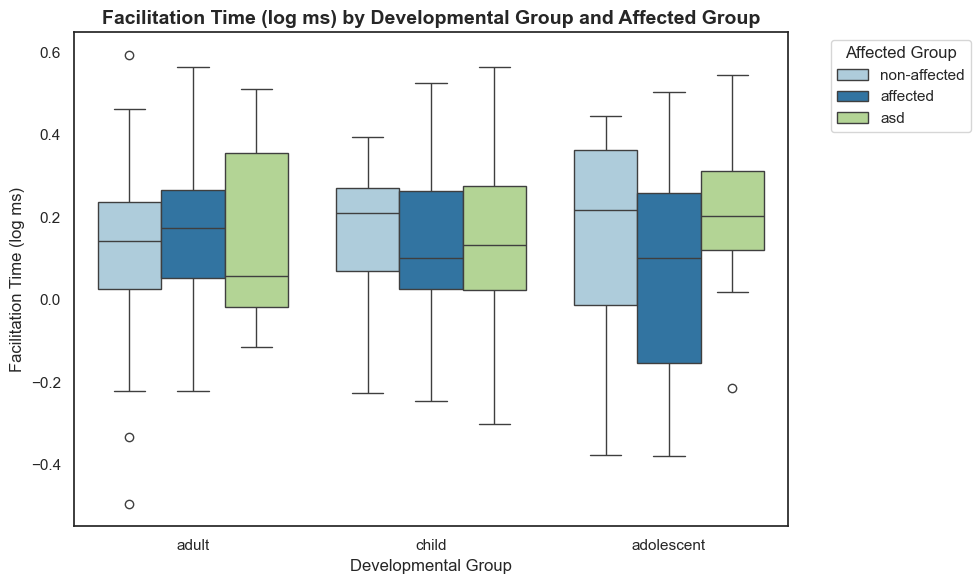

affected_group developmental_group  N  Mean    SD  Median    Min   Max  N_Subjects
      affected          adolescent 17 0.063 0.275   0.102 -0.378 0.505          17
      affected               adult 30 0.160 0.183   0.173 -0.220 0.564          30
      affected               child 22 0.129 0.191   0.101 -0.245 0.527          22
           asd          adolescent 14 0.209 0.195   0.204 -0.215 0.545          14
           asd               adult 12 0.148 0.226   0.059 -0.115 0.512          12
           asd               child 23 0.137 0.203   0.134 -0.301 0.564          23
  non-affected          adolescent  7 0.141 0.310   0.218 -0.376 0.446           7
  non-affected               adult 98 0.124 0.177   0.142 -0.495 0.594          98
  non-affected               child 16 0.159 0.160   0.210 -0.227 0.396          16
✓ Figure saved: 13_disengagement_affected_group_by_developmental_group.png
Added to Word document


<Figure size 640x480 with 0 Axes>

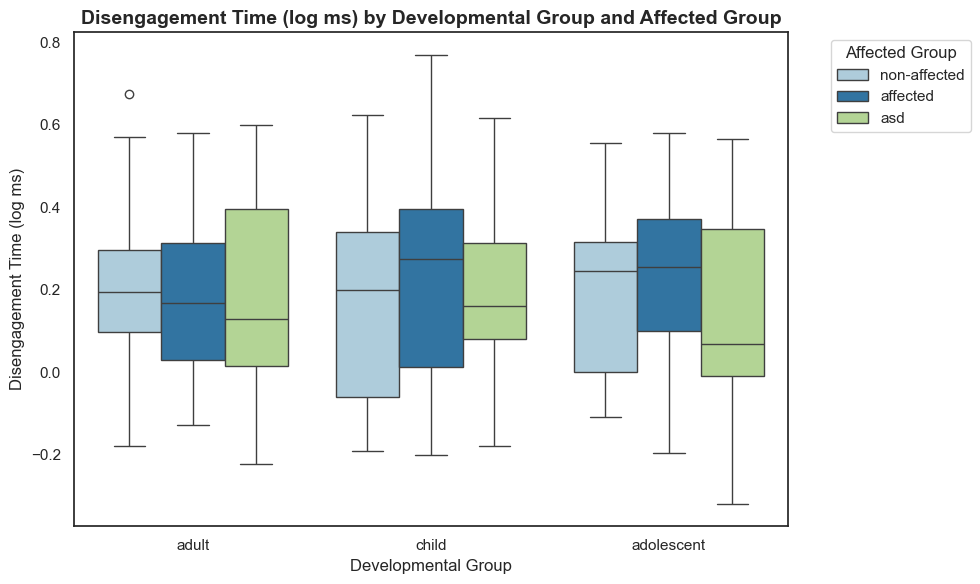

affected_group developmental_group  N  Mean    SD  Median    Min   Max  N_Subjects
      affected          adolescent 17 0.219 0.223   0.256 -0.196 0.580          17
      affected               adult 30 0.177 0.190   0.168 -0.128 0.580          30
      affected               child 22 0.246 0.266   0.275 -0.202 0.770          22
           asd          adolescent 14 0.156 0.265   0.069 -0.319 0.567          14
           asd               adult 12 0.183 0.245   0.128 -0.222 0.600          12
           asd               child 23 0.190 0.173   0.160 -0.179 0.617          23
  non-affected          adolescent  7 0.190 0.236   0.247 -0.108 0.557           7
  non-affected               adult 98 0.200 0.167   0.194 -0.179 0.675          98
  non-affected               child 16 0.188 0.266   0.200 -0.192 0.623          16


<Figure size 640x480 with 0 Axes>

In [126]:
# Facilitation by NDD
fig1, stats1 = visualize_and_summarize(
    df=go_dis,
    grouping_var='ndd',
    dv='facilitation',
    condition="developmental_group",
    fig_num=8,
    palette='Paired',
    doc=doc,
    dv_label='Facilitation Time (log ms)'
)

# Disengagement by NDD
fig2, stats2 = visualize_and_summarize(
    df=go_dis,
    grouping_var='ndd',
    dv='disengagement',
    condition="developmental_group",
    fig_num=9,
    palette='Paired',
    doc=doc,
    dv_label='Disengagement Time (log ms)'
)

# Facilitation by ASD
fig3, stats3 = visualize_and_summarize(
    df=go_dis,
    grouping_var='asd',
    dv='facilitation',
    condition="developmental_group",
    fig_num=10,
    palette='Paired',
    doc=doc,
    dv_label='Facilitation Time (log ms)'
)

# Disengagement by ASD
fig4, stats4 = visualize_and_summarize(
    df=go_dis,
    grouping_var='asd',
    dv='disengagement',
    condition="developmental_group",
    fig_num=11,
    palette='Paired',
    doc=doc,
    dv_label='Disengagement Time (log ms)'
)

# Facilitation by affected_group
fig5, stats5 = visualize_and_summarize(
    df=go_dis,
    grouping_var='affected_group',
    dv='facilitation',
    condition="developmental_group",
    fig_num=12,
    palette='Paired',
    doc=doc,
    dv_label='Facilitation Time (log ms)'
)
# Disengagement by affected_group
fig6, stats6 = visualize_and_summarize(
    df=go_dis,
    grouping_var='affected_group',
    dv='disengagement',
    condition="developmental_group",
    fig_num=13,
    palette='Paired',
    doc=doc,
    dv_label='Disengagement Time (log ms)'
)

#### Save the Gap outputs

In [127]:
go_dis.to_csv(f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/gap/go_rt_sub_clean.csv", index=False)

In [129]:
# Save the document
doc_save_path = f"C:/Users/gabot/OneDrive - McGill University/Desktop/github_repos/q1k_neurosubs/outputs/word_document/4_Reaction_Time_Analysis.docx"
doc.save(doc_save_path)